<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/04_Quantum_Complexity_Environment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring Quantum Complexity in an $L$-qubit Quantum Kicked Top

This notebook delves into the dynamics of a many-body quantum system, specifically an $L$-qubit Quantum Kicked Top, evolving under a global Hamiltonian. We investigate how interactions among all subsystems generate correlations and entanglement over time.

The Hamiltonian for the quantum kicked top is given by:

$$H(t) = \frac{\pi}{2\tau} J_y + \frac{\kappa}{2j} J_z^2 \sum_{n=1}^{N}\delta(t-n\tau).$$

The first term induces a collective rotation of all spins about the $y$-axis, while the second term introduces nonlinear interactions with strength $ \kappa/2j$. The operators $J_y$ and $J_z$ are defined as $J_y = \frac{\hbar}{2}\sum_{i=1}^{L} \sigma_y^{(i)}$ and $J_z = \frac{\hbar}{2}\sum_{i=1}^{L} \sigma_z^{(i)}$. The nonlinear term $J_z^2$ expands to:

$$\begin{equation}J_z^2 = \frac{\hbar^2}{4}\left( L I + 2\sum_{i<k}\sigma_z^{(i)} \sigma_z^{(k)} \right ).\end{equation}$$

The unitary evolution over one cycle is described by the Floquet operator:

$$U_F = e^{-i(\kappa/2j \hbar)J_z^2}e^{-i(\pi/2\hbar)J_y}$$

This Floquet operator drives the system away from a product structure, leading to the generation of multipartite entanglement. This notebook focuses on exploring how increasing the number of qubits ($L$) affects various measures of complexity within the system.

# Current Notebook: Impact of System Size ($L$) on Complexity

Building upon previous explorations of interaction strength, this notebook investigates the effect of varying the number of qubits ($L$) on measures of complexity in the $L$-qubit kicked top.

Key aspects explored include:

1.  **Increased Interactions for $L>3$**: For systems with $L>3$ qubits, the collective $J_z^2$ interaction introduces additional non-nearest-neighbor couplings beyond those present in smaller systems. This leads to increased entanglement generation and provides more channels through which perturbations can propagate. Consequently, this influences both local instability (measured by $\Gamma$) and global spreading (measured by $\mathcal{S}_1$).

2.  **Symmetry Properties and Dynamics**: The system size also dictates the symmetry properties of the Hamiltonian. Even- and odd-qubit systems exhibit distinct parity symmetries, which are inherited by the Floquet operator. These differences can lead to qualitative shifts in the system's dynamics.

In [1]:
!rm -rf Qaos
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Qaos.git

# Move into the repo
%cd Qaos

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gqs.states import Initial_state
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance
from gqs.dynamics import Hamiltonian_QK, floquet_operator_from_H
from gqs.PlotsDynamics import plot_two_gqs_trajectory_row
from gqs.Gamma import Compare_distances_All, Gamma_calculator
from gqs.SSCI import SSCI_calculator

Running for L = 3


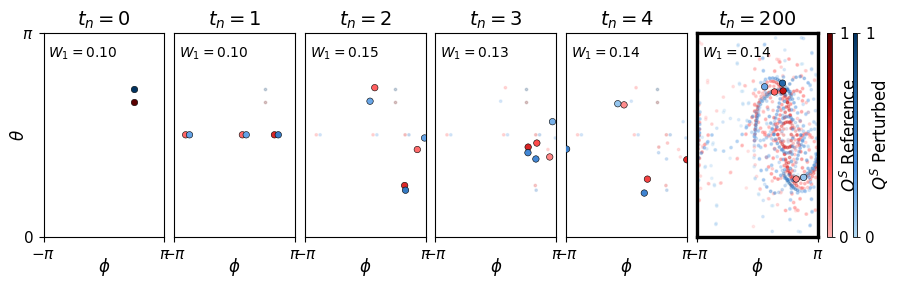




Running for L = 4


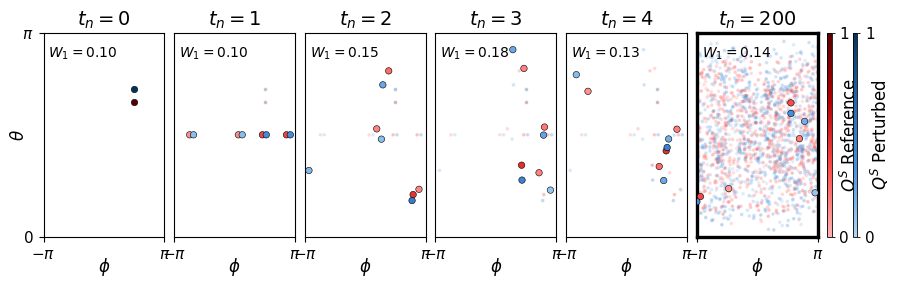




Running for L = 5


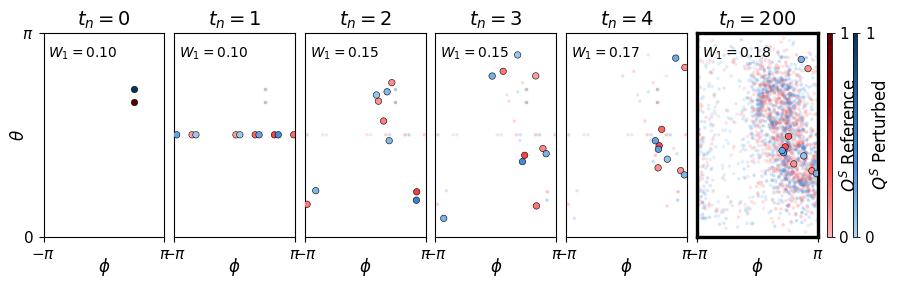




Running for L = 6


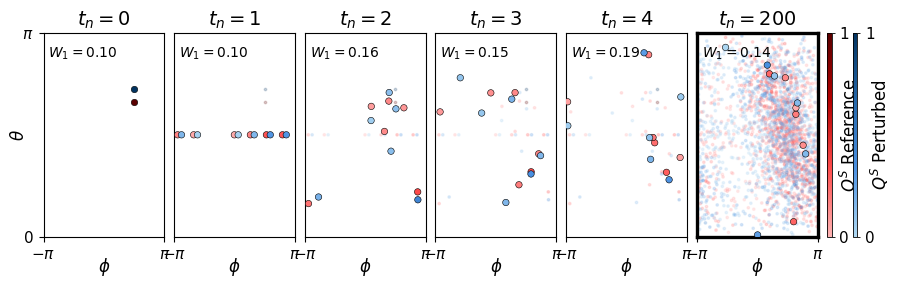

In [7]:
nqubitArr = [3,4,5,6]
kappa = 2.5                                     # <--- kappa- interaction strength, nqubits - number of qubits in kicked top
# Two neighboring Global States - taken to be a spin coherent state but can be changed to a more general Psi
theta, phi, eps = np.pi/2+0.5, np.pi/2, 0.2

for nqubit in nqubitArr:
  print(rf"Running for L = {nqubit}")
  #Dynamics of the reduced states
  H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit) # <--- Quantum Kicked Top Hamiltonian,
  U_F = floquet_operator_from_H(H1,H2,tau=1.0,)              # <--- Floquet operator from QKT Hamiltonian
  psi_reference = Initial_state(nqubit,theta,phi)
  psi_perturbed = Initial_state(nqubit, theta+eps, phi)
  _= plot_two_gqs_trajectory_row(U_F=U_F, psi_reference=psi_reference, psi_perturbed=psi_perturbed, selected_kicks=(0,1,2,3,4,200))
  print("\n\n")




# Quantifying complexity with changing environment size - Sensitivity

Running for L = 3


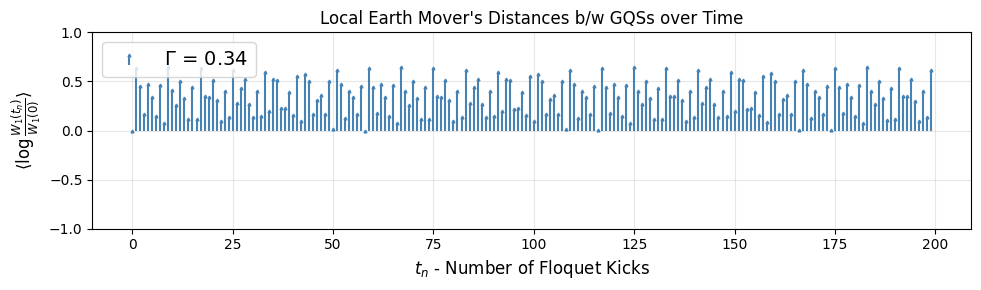




Running for L = 4


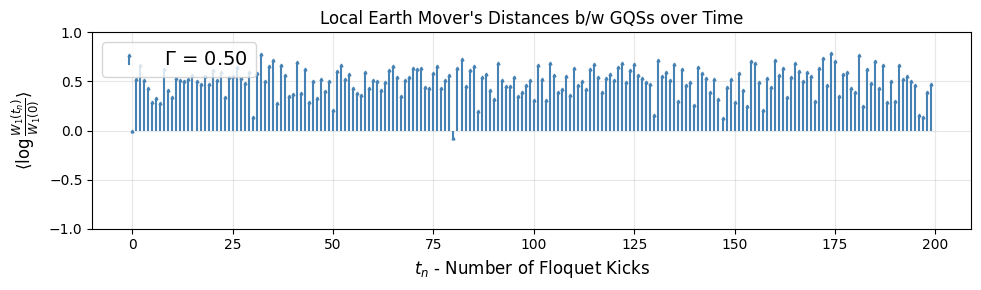




Running for L = 5


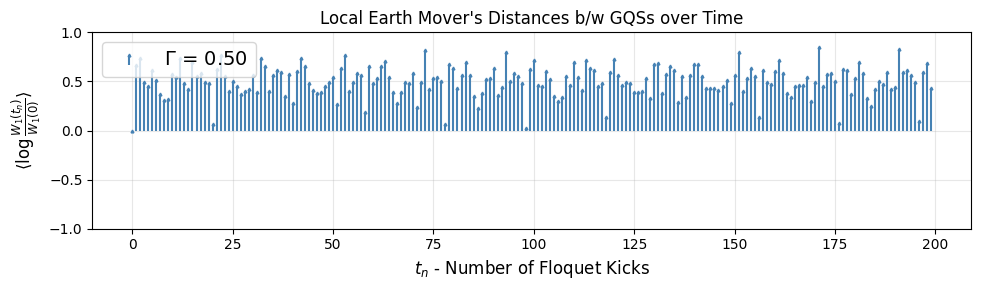




Running for L = 6


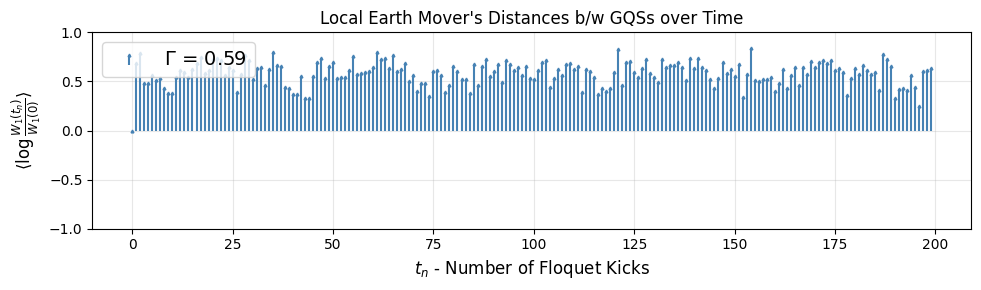

In [8]:
for nqubit in nqubitArr:
    print(rf"Running for L = {nqubit}")
    #Dynamics of the reduced states
    H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit) # <--- Quantum Kicked Top Hamiltonian,
    U_F = floquet_operator_from_H(H1,H2,tau=1.0,)              # <--- Floquet operator from QKT Hamiltonian
    _=Gamma_calculator(U_F,nqubit=nqubit,theta0=theta,phi0=phi,eps=eps,N_traj=10,N_kicks=200,show_plot=True)
    print("\n\n")


# Quantifying complexity with changing environment size - Spread

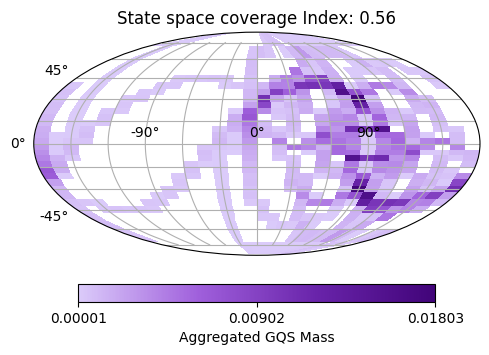

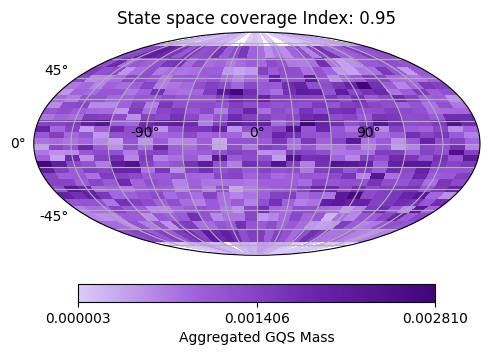

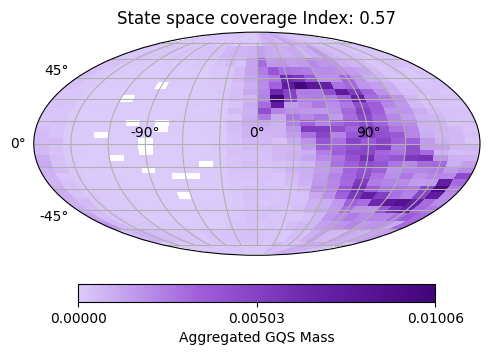

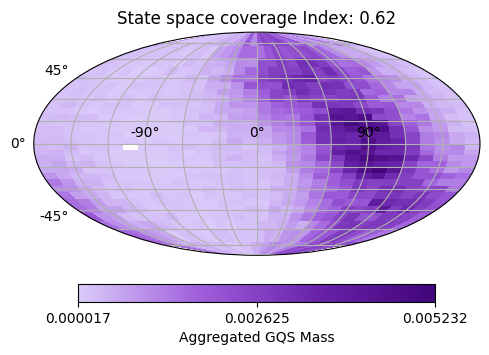

In [ ]:
for nqubit in nqubitArr:
    print(rf"Running for L = {nqubit}")
    #Dynamics of the reduced states
    H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit) # <--- Quantum Kicked Top Hamiltonian,
    U_F = floquet_operator_from_H(H1,H2,tau=1.0,)              # <--- Floquet operator from QKT Hamiltonian
    _=SSCI_calculator(kappa=kappa,nqubit=nqubit,nkicks=5000,theta=theta,phi=phi,show_plot=True,)
    print("\n\n")

# Summary of Findings

In this notebook, we have investigated the quantum dynamics of an L-qubit kicked top system by varying the number of qubits, L. We observed how increasing L impacts the system's complexity through various measures, including state space coverage and local instability. The results highlight the intricate relationship between system size, interaction pathways, entanglement generation, and the overall chaotic behavior of the quantum kicked top.